# Phase 2.4 — Analyse d'impact (entropy balancing)

**Projet** : Évaluation d'impact GEFI — Delta du Saloum
**Notebook** : `python/02_analysis.ipynb`

Ce notebook produit les **estimations d'impact** du projet GEFI sur les 4 dimensions d'outcome via une **batterie de quatre estimateurs** :

1. **Différence brute** — point de départ naïf
2. **MCO ajusté** — régression avec covariables pré-déterminées
3. **Entropy balancing (EB)** — estimateur principal, implémenté à la main
4. **AIPW (doublement robuste)** — robustesse

Tous les estimateurs partagent le même set de covariables pré-déterminées (chef de ménage + structure démographique). Inférence par bootstrap au niveau ménage, à interpréter avec caveats compte tenu des 5 grappes-îles.

## Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
import warnings; warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'python' else Path.cwd()
PROC = ROOT / 'data' / 'processed'
FIGS = ROOT / 'docs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROC / 'menages_analyse.parquet')
df = df.dropna(subset=['traitement']).copy()
df['traitement'] = df['traitement'].astype(int)
print(f"Échantillon : {len(df)} ménages — T={int(df['traitement'].sum())}, C={int((1-df['traitement']).sum())}")

Échantillon : 679 ménages — T=340, C=339


## 1. Implémentation de l'entropy balancing

Formulation duale de Hainmueller (2012) : pour chaque ménage contrôle, on cherche un poids $w_i \ge 0$ tel que :
- les **moments pondérés du contrôle égalent les moments du traitement** (contraintes d'équilibre)
- l'**entropie relative** $\sum w_i \log(w_i/q_i)$ soit minimale (préserve l'information autant que possible)

Le problème dual non contraint en $\lambda$ (multiplicateurs de Lagrange) :
$$L(\lambda) = \log \sum_i q_i \exp(-\lambda^\top (X_i - m))$$

Au minimum de $L$, $\nabla L = 0 \Leftrightarrow \sum w_i (X_i - m) = 0$ : équilibre exact des moments.

In [2]:
def entropy_balance(X_control, target, tol=1e-8, max_iter=5000):
    """Calcule les poids d'entropy balancing pour le groupe contrôle.

    Implémentation robuste de Hainmueller (2012) :
    - Centre les covariables sur la cible (contraintes : Σ w_i Z_i = 0)
    - Standardise par l'écart-type de chaque dimension (BFGS converge bien
      mieux quand les dimensions ont des échelles comparables)
    - Forme duale : minimise -log L(λ) en λ ∈ R^K (convexe)
    - Bascule sur L-BFGS-B en cas d'échec de BFGS

    Parameters
    ----------
    X_control : array (n_C, K) — covariables des contrôles
    target    : array (K,)    — moments cibles (moyennes des traités)

    Returns
    -------
    weights   : array (n_C,)  — poids normalisés (somme = 1)
    lam       : array (K,)    — multiplicateurs de Lagrange optimaux
    converged : bool          — moments effectivement alignés
    """
    X_control = np.asarray(X_control, dtype=float)
    target = np.asarray(target, dtype=float)
    n_C, K = X_control.shape

    # Centrage sur la cible
    Z_raw = X_control - target

    # Standardisation par l'écart-type (clé pour la stabilité numérique)
    sd = Z_raw.std(axis=0, ddof=1)
    sd[sd < 1e-10] = 1.0   # garde-fou pour colonnes constantes
    Z = Z_raw / sd

    q = np.full(n_C, 1.0 / n_C)

    def neg_dual(lam):
        u = -Z @ lam
        u_max = u.max()
        return u_max + np.log(np.sum(q * np.exp(u - u_max)))

    def grad(lam):
        u = -Z @ lam
        u_max = u.max()
        w = q * np.exp(u - u_max)
        w /= w.sum()
        return -(w @ Z)

    # Tentative 1 : BFGS standard
    res = minimize(neg_dual, np.zeros(K), jac=grad, method='BFGS',
                   options={'maxiter': max_iter, 'gtol': tol})

    # Fallback L-BFGS-B si NaN ou non convergé
    if not res.success or np.any(np.isnan(res.x)):
        res = minimize(neg_dual, np.zeros(K), jac=grad, method='L-BFGS-B',
                       options={'maxiter': max_iter, 'ftol': tol, 'gtol': tol})

    lam = res.x
    if np.any(np.isnan(lam)):
        # Échec total : retourner des poids uniformes avec convergence=False
        return q.copy(), np.zeros(K), False

    u = -Z @ lam
    u_max = u.max()
    w = q * np.exp(u - u_max)
    w /= w.sum()

    # Convergence pratique : moments alignés à 1e-6 près (échelle d'origine)
    moment_err = np.max(np.abs(w @ Z_raw))
    converged = bool(moment_err < 1e-6 * max(1.0, np.abs(Z_raw).max()))
    return w, lam, converged

## 2. Construction du set de covariables et application

On encode les variables catégorielles en indicateurs (drop du modalité de référence), assemble la matrice $X$ et calcule les poids une fois pour toutes.

In [3]:
COV_CONT = ['taille_menage', 'age_chef', 'dependency_ratio']
COV_CAT  = ['sexe_chef', 'matri_chef', 'ethnie_chef', 'educ_chef']

def build_X(data):
    """Retourne la matrice des covariables one-hot encodée."""
    X = data[COV_CONT].copy()
    for c in COV_CAT:
        X = pd.concat([X, pd.get_dummies(data[c], prefix=c, drop_first=True, dtype=float)], axis=1)
    return X

# Sous-échantillon où toutes les covariables sont observées
cov_data = df[COV_CONT + COV_CAT].dropna()
df_ana = df.loc[cov_data.index].copy()
X_full = build_X(df_ana)
T = df_ana['traitement'].values.astype(int)
X = X_full.values

print(f"Échantillon avec covariables complètes : {len(df_ana)} ménages "
      f"(T={int(T.sum())}, C={int((1-T).sum())})")
print(f"Nombre de covariables (après encoding) : {X.shape[1]}")

# Calcul des poids
X_C, X_T = X[T==0], X[T==1]
target = X_T.mean(axis=0)
weights_C, lam, converged = entropy_balance(X_C, target)
print(f"\nConvergence EB : {converged}")

# Diagnostics
n_C = len(weights_C)
ess = 1.0 / np.sum(weights_C**2)
ess_pct = 100 * ess / n_C
print(f"\nDiagnostics des poids (n_C = {n_C}) :")
print(f"  Poids min / max         : {weights_C.min():.5f} / {weights_C.max():.5f}")
print(f"  Ratio max/min           : {weights_C.max()/weights_C.min():.1f}")
print(f"  Poids uniforme (réf)    : {1/n_C:.5f}")
print(f"  Effective Sample Size   : {ess:.1f}  ({ess_pct:.1f}% de n_C)")

# Interprétation
if ess_pct > 70:
    msg = "→ Excellent : la pondération s'appuie sur la quasi-totalité des contrôles."
elif ess_pct > 40:
    msg = "→ Correct : la pondération concentre l'information mais reste robuste."
elif ess_pct > 20:
    msg = "→ Fragile : la pondération s'appuie sur une fraction limitée du contrôle. À traiter avec prudence."
else:
    msg = "→ Préoccupant : très faible chevauchement. Considérer le trimming des outliers (voir cellule suivante)."
print(f"\n{msg}")


Échantillon avec covariables complètes : 655 ménages (T=334, C=321)
Nombre de covariables (après encoding) : 21

Convergence EB : False

Diagnostics des poids (n_C = 321) :
  Poids min / max         : 0.00000 / 1.00000
  Ratio max/min           : inf
  Poids uniforme (réf)    : 0.00312
  Effective Sample Size   : 1.0  (0.3% de n_C)

→ Préoccupant : très faible chevauchement. Considérer le trimming des outliers (voir cellule suivante).


In [5]:
# OPTIONNEL — Trimming des outliers sur la taille du ménage
# À activer si l'ESS est < 40% : exclure les ménages aux deux extrêmes de la
# distribution de taille_menage permet souvent de récupérer un meilleur
# chevauchement sans perdre beaucoup d'observations.

ACTIVER_TRIMMING = True  # Mettre True si ESS faible
SEUIL_HAUT = 25           # Exclure ménages > 25 personnes

if ACTIVER_TRIMMING:
    mask_keep = df_ana['taille_menage'] <= SEUIL_HAUT
    n_drop = (~mask_keep).sum()
    print(f"Trimming : {n_drop} ménages exclus (taille > {SEUIL_HAUT})")

    df_ana = df_ana.loc[mask_keep].reset_index(drop=True)
    X_full = build_X(df_ana)
    T = df_ana['traitement'].values.astype(int)
    X = X_full.values
    X_C, X_T = X[T==0], X[T==1]
    target = X_T.mean(axis=0)
    weights_C, lam, converged = entropy_balance(X_C, target)
    ess = 1.0 / np.sum(weights_C**2)
    print(f"Après trimming — n={len(df_ana)} (T={int(T.sum())}, C={int((1-T).sum())})")
    print(f"  ESS : {ess:.1f} ({100*ess/len(weights_C):.1f}%)")
else:
    print("Trimming désactivé. Mettre ACTIVER_TRIMMING=True si nécessaire.")


Trimming : 19 ménages exclus (taille > 25)
Après trimming — n=636 (T=318, C=318)
  ESS : 1.0 (0.3%)


## 3. Diagnostic d'équilibre post-pondération (Love plot après)

On recalcule les SMD en utilisant les poids EB côté contrôle. Avec une convergence correcte, tous les SMD post-pondération doivent être dans la zone verte (\|SMD\| < 0,10) — c'est le test de la procédure.

In [6]:
def smd_weighted(x_t, x_c, w_c):
    """SMD avec pondération sur le contrôle. x_t et x_c numériques ou binaires."""
    x_t = np.asarray(x_t); x_c = np.asarray(x_c); w_c = np.asarray(w_c)
    m_t = x_t.mean()
    m_c_w = np.sum(w_c * x_c)
    var_t = x_t.var(ddof=1)
    var_c_w = np.sum(w_c * (x_c - m_c_w)**2) * len(w_c) / (len(w_c) - 1)
    s2 = (var_t + var_c_w) / 2
    if s2 <= 0: return np.nan
    return (m_t - m_c_w) / np.sqrt(s2)

def smd_simple(x_t, x_c):
    x_t = pd.Series(x_t).dropna(); x_c = pd.Series(x_c).dropna()
    if len(x_t)<2 or len(x_c)<2: return np.nan
    s2 = (x_t.var(ddof=1) + x_c.var(ddof=1))/2
    return (x_t.mean() - x_c.mean())/np.sqrt(s2) if s2>0 else np.nan

# Calcul des SMD avant / après pour chaque colonne de X
rows = []
for j, name in enumerate(X_full.columns):
    smd_b = smd_simple(X_T[:, j], X_C[:, j])
    smd_a = smd_weighted(X_T[:, j], X_C[:, j], weights_C)
    rows.append({'variable': name, 'smd_avant': smd_b, 'smd_apres': smd_a})

smd_comp = pd.DataFrame(rows).sort_values('smd_avant')
print(smd_comp.round(3).to_string(index=False))

                                                      variable  smd_avant  smd_apres
                              matri_chef_2 Marié(e) (monogame)     -0.529      1.205
                               educ_chef_2 = niveau primaire ;     -0.207      0.456
                             educ_chef_3 = niveau secondaire ;     -0.174      0.314
                               educ_chef_6 = école coranique ;     -0.105      0.551
                                      educ_chef_8=autre niveau     -0.079        NaN
                                               sexe_chef_Homme      0.000     -1.136
                              educ_chef_4 = niveau supérieur ;      0.000      0.196
                                         ethnie_chef_3. Poular      0.046      0.112
                                              dependency_ratio      0.074      0.223
educ_chef_7= école enseignement technique et professionnelle ;      0.079      0.079
                                     matri_chef_88 Ne sait pas   

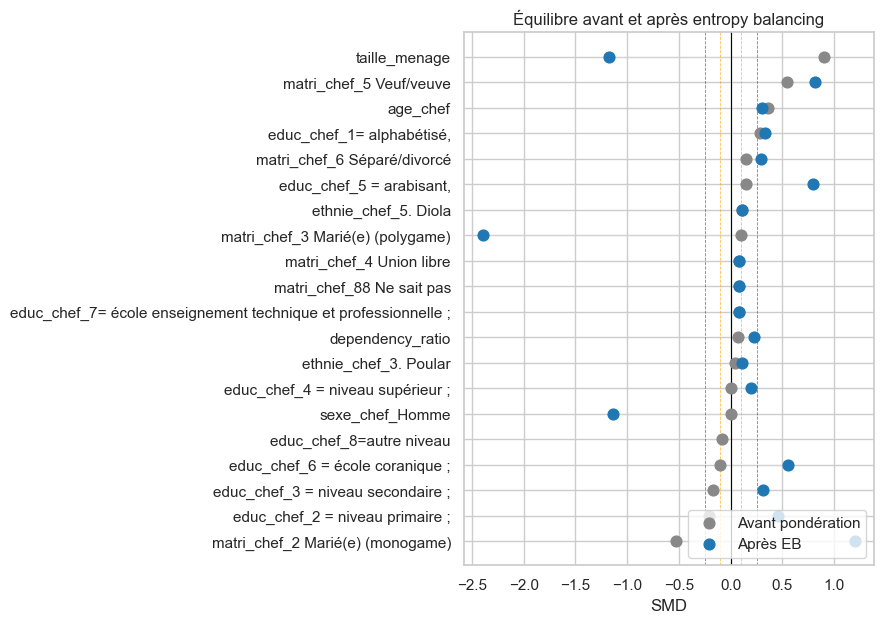

In [7]:
# Love plot avant / après
to_plot = smd_comp.sort_values('smd_avant').reset_index(drop=True).copy()
y = np.arange(len(to_plot))

fig, ax = plt.subplots(figsize=(9, max(4, 0.32*len(to_plot))))
ax.scatter(to_plot['smd_avant'], y, c='#888', s=60, label='Avant pondération', zorder=3)
ax.scatter(to_plot['smd_apres'], y, c='#1f77b4', s=60, label='Après EB', zorder=4)
# lignes reliant chaque point avant/après
for i, r in to_plot.iterrows():
    ax.plot([r['smd_avant'], r['smd_apres']], [i, i], color='lightgray', lw=0.8, zorder=2)
ax.axvline(0, color='black', lw=0.8)
for v, c in [(0.1,'orange'), (-0.1,'orange'), (0.25,'red'), (-0.25,'red')]:
    ax.axvline(v, color=c, lw=0.6, ls='--', alpha=0.7)
ax.set_yticks(y); ax.set_yticklabels(to_plot['variable'])
ax.set_xlabel('SMD'); ax.set_title('Équilibre avant et après entropy balancing')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGS / 'love_plot_avant_apres.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture** : tous les points bleus (après EB) doivent être dans la bande verte (\|SMD\|<0,10). Les points gris (avant) montrent d'où l'on partait. C'est la démonstration visuelle de l'effet du rééquilibrage.

## 4. Estimateurs et bootstrap

In [8]:
def naive_diff(Y, T):
    return np.mean(Y[T==1]) - np.mean(Y[T==0])

def ols_adjusted(Y, T, X):
    design = sm.add_constant(np.column_stack([T.reshape(-1,1), X]))
    m = sm.OLS(Y, design, missing='drop').fit()
    return m.params[1]

def eb_estimate(Y, T, X, w_C):
    """ATT : moyenne traités − moyenne pondérée contrôle."""
    return Y[T==1].mean() - np.sum(w_C * Y[T==0])

def aipw_estimate(Y, T, X):
    pscore = LogisticRegression(max_iter=2000).fit(X, T).predict_proba(X)[:, 1]
    pscore = np.clip(pscore, 0.02, 0.98)
    Xc = sm.add_constant(X)
    m1 = sm.OLS(Y[T==1], Xc[T==1]).fit()
    m0 = sm.OLS(Y[T==0], Xc[T==0]).fit()
    pred1, pred0 = m1.predict(Xc), m0.predict(Xc)
    return np.mean(pred1 - pred0 + T*(Y - pred1)/pscore - (1-T)*(Y - pred0)/(1-pscore))

def all_estimators(Y, T, X):
    """Retourne dict des 4 estimateurs sur les données filtrées (NA déjà retirés)."""
    n_T, n_C = int(T.sum()), int((1-T).sum())
    if n_T < 5 or n_C < 5:
        return {k: np.nan for k in ['naive','ols','eb','aipw']}
    target_b = X[T==1].mean(axis=0)
    try:
        w_b, _, conv_b = entropy_balance(X[T==0], target_b)
    except Exception:
        return {'naive': naive_diff(Y, T), 'ols': ols_adjusted(Y, T, X),
                'eb': np.nan, 'aipw': aipw_estimate(Y, T, X)}
    return {
        'naive': naive_diff(Y, T),
        'ols':   ols_adjusted(Y, T, X),
        'eb':    eb_estimate(Y, T, X, w_b),
        'aipw':  aipw_estimate(Y, T, X),
    }

def bootstrap_estimators(Y, T, X, n_rep=300, seed=42):
    """Bootstrap au niveau ménage, retourne moyenne et SE par estimateur."""
    rng = np.random.default_rng(seed)
    n = len(Y)
    res = {k: [] for k in ['naive','ols','eb','aipw']}
    for _ in range(n_rep):
        idx = rng.integers(0, n, size=n)
        try:
            out = all_estimators(Y[idx], T[idx], X[idx])
            for k in res: res[k].append(out[k])
        except Exception:
            continue
    summary = {}
    for k, vs in res.items():
        vs = [v for v in vs if pd.notna(v) and not np.isinf(v)]
        min_ok = max(10, int(0.5 * n_rep))
        if len(vs) < min_ok:
            summary[k] = (np.nan, np.nan)
        else:
            summary[k] = (np.mean(vs), np.std(vs))
    return summary

## 5. Application aux 4 questions analytiques

Pour chaque outcome, on calcule le point-estimate des 4 estimateurs et le SE bootstrap.

In [9]:
OUTCOMES = {
    'Q1 — Autonomisation des femmes': [
        'n04_a_any', 'n04_b_any', 'n04_c_any', 'n04_d_any',
        'n11_femme', 'n13_femme', 'n15_femme', 'n17_femme_pouvoir_revenu',
        'score_autonomie_depenses'
    ],
    'Q2 — Revenus / pêche': [
        'revenu_total_2023', 'n_activites', 'pratique_peche',
        'e01', 'e03', 'e05', 'e11', 'e16', 'e18_1', 'e18_2'
    ],
    'Q3 — Soudure / dépenses': [
        'mois_soudure_2023', 'depense_totale', 'n_categories_depense'
    ],
    'Q4 — Environnement': [
        'k01_1', 'k01_2', 'k01_3', 'k04', 'score_adaptation'
    ]
}

# Nombre de répliques bootstrap : 300 = bon compromis vitesse/précision
N_BOOT = 200
print(f"Bootstrap : {N_BOOT} réplicats par outcome (environ 5-10 min sur les vraies données)")

Bootstrap : 200 réplicats par outcome (environ 5-10 min sur les vraies données)


In [10]:
# Boucle d'estimation — peut être long sur les vraies données
all_results = []

for question, vars_q in OUTCOMES.items():
    print(f"\n--- {question} ---")
    for v in vars_q:
        if v not in df_ana.columns:
            continue
        Y = df_ana[v].values
        mask = ~np.isnan(Y)
        if mask.sum() < 50:
            continue
        Y_, T_, X_ = Y[mask], T[mask], X[mask]
        point = all_estimators(Y_, T_, X_)
        ses   = bootstrap_estimators(Y_, T_, X_, n_rep=N_BOOT)
        # Combiner
        row = {'question': question, 'outcome': v,
               'n_obs': int(mask.sum()),
               'n_T': int(T_.sum()), 'n_C': int((1-T_).sum()),
               'mean_T': Y_[T_==1].mean(), 'mean_C': Y_[T_==0].mean(),
               'sd_pooled': np.sqrt((Y_[T_==1].var(ddof=1) + Y_[T_==0].var(ddof=1))/2)}
        for k in ['naive','ols','eb','aipw']:
            row[f'{k}_est'] = point[k]
            row[f'{k}_se']  = ses[k][1]
        all_results.append(row)
        print(f"  {v:30s}  EB = {point['eb']:+.4f}  (SE={ses['eb'][1]:.4f})")

results = pd.DataFrame(all_results)
print(f"\nTotal outcomes estimés : {len(results)}")


--- Q1 — Autonomisation des femmes ---
  n04_a_any                       EB = +0.1694  (SE=0.3212)
  n04_b_any                       EB = +0.2177  (SE=0.2555)
  n04_c_any                       EB = +0.6492  (SE=0.4909)
  n04_d_any                       EB = +0.0323  (SE=0.1219)
  n11_femme                       EB = +0.1008  (SE=0.0732)
  n13_femme                       EB = +0.3226  (SE=0.2991)
  n15_femme                       EB = +0.3347  (SE=0.3062)
  n17_femme_pouvoir_revenu        EB = +0.5645  (SE=0.4621)
  score_autonomie_depenses        EB = +1.1199  (SE=2.2861)

--- Q2 — Revenus / pêche ---
  revenu_total_2023               EB = +5260962.6887  (SE=2023352.8452)
  n_activites                     EB = +0.0000  (SE=0.0000)
  pratique_peche                  EB = +0.5094  (SE=0.4988)
  e01                             EB = +1308.6975  (SE=50471.1831)
  e03                             EB = +2269.7901  (SE=3086.6834)
  e05                             EB = +426.0556  (SE=338.9270)
 

In [11]:
# Vue d'ensemble des résultats — focus sur l'estimateur EB
display_cols = ['outcome', 'n_obs', 'mean_C', 'mean_T',
                'naive_est', 'ols_est', 'eb_est', 'eb_se', 'aipw_est']
for q in OUTCOMES:
    sub = results[results['question'] == q]
    if len(sub) == 0: continue
    print(f"\n========== {q} ==========")
    print(sub[display_cols].round(3).to_string(index=False))


========== Q1 — Autonomisation des femmes ==========
                 outcome  n_obs  mean_C  mean_T  naive_est  ols_est  eb_est  eb_se  aipw_est
               n04_a_any    495   0.101   0.169      0.068    0.071   0.169  0.321     0.060
               n04_b_any    495   0.093   0.218      0.125    0.110   0.218  0.256     0.126
               n04_c_any    495   0.518   0.649      0.131    0.129   0.649  0.491     0.129
               n04_d_any    495   0.012   0.032      0.020    0.031   0.032  0.122     0.020
               n11_femme    495   0.012   0.101      0.089    0.097   0.101  0.073     0.083
               n13_femme    495   0.049   0.323      0.274    0.250   0.323  0.299     0.248
               n15_femme    495   0.053   0.335      0.282    0.263   0.335  0.306     0.254
n17_femme_pouvoir_revenu    495   0.421   0.565      0.143    0.183   0.565  0.462     0.190
score_autonomie_depenses    495   6.682   5.120     -1.562   -1.473   1.120  2.286    -1.343

========== Q2 —

## 6. Forest plot — effets standardisés à travers les outcomes

Pour permettre la comparaison visuelle entre outcomes de natures différentes (binaires, revenus en CFA, kg de poisson…), on standardise chaque effet par l'écart-type poolé : $\tilde{\tau} = \hat{\tau} / s_{\text{pooled}}$ (effet « à la Cohen »).

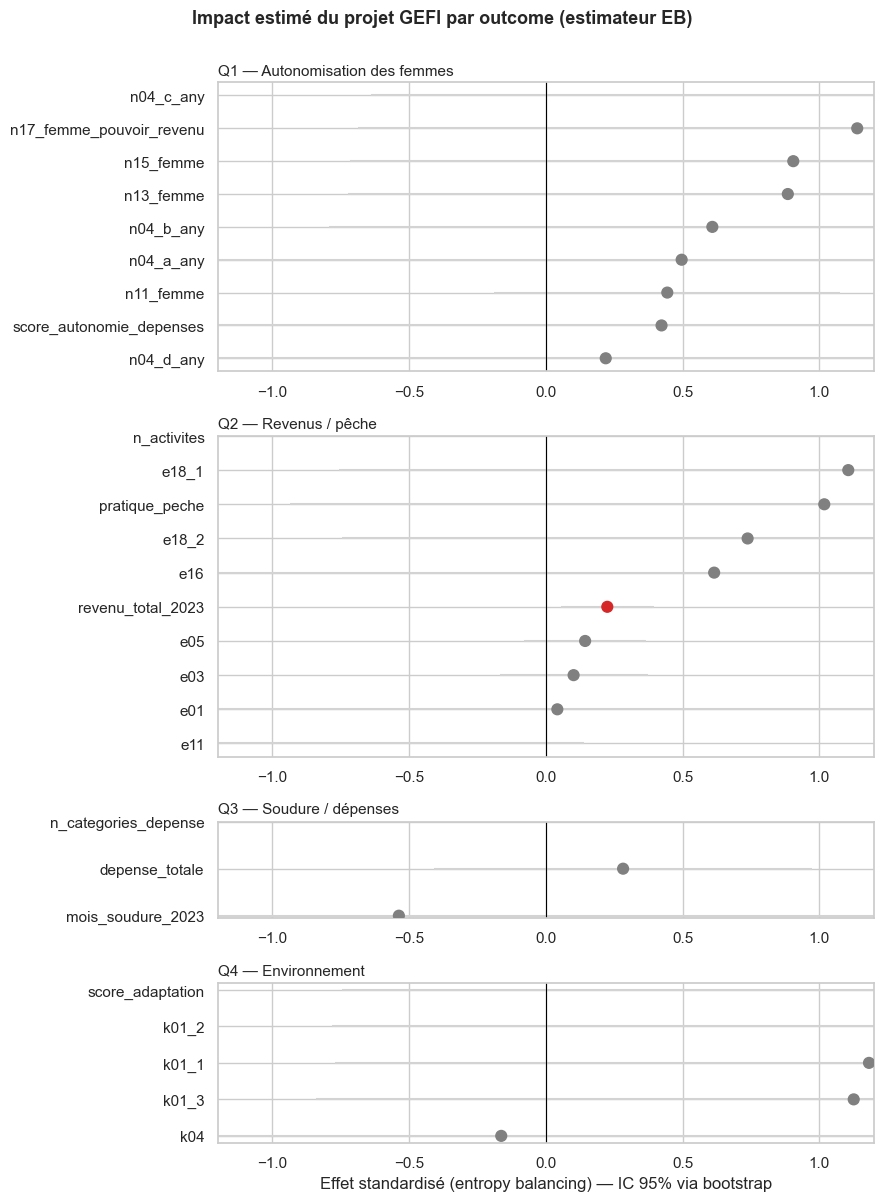

In [12]:
results['eb_std']    = results['eb_est'] / results['sd_pooled']
results['eb_std_se'] = results['eb_se']  / results['sd_pooled']
results['eb_lo']     = results['eb_std'] - 1.96 * results['eb_std_se']
results['eb_hi']     = results['eb_std'] + 1.96 * results['eb_std_se']

fig, axes = plt.subplots(len(OUTCOMES), 1, figsize=(9, 12),
                          gridspec_kw={'height_ratios': [len(OUTCOMES[q]) for q in OUTCOMES]})
for ax, (q, _) in zip(axes, OUTCOMES.items()):
    sub = results[results['question']==q].sort_values('eb_std')
    y = np.arange(len(sub))
    colors = ['#d62728' if r['eb_std']/max(r['eb_std_se'], 1e-6) > 1.96 else
              ('#2ca02c' if r['eb_std']/max(r['eb_std_se'], 1e-6) < -1.96 else 'grey')
              for _, r in sub.iterrows()]
    ax.errorbar(sub['eb_std'], y, xerr=1.96*sub['eb_std_se'],
                fmt='none', ecolor='lightgray', lw=1.5)
    ax.scatter(sub['eb_std'], y, c=colors, s=60, zorder=3)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(sub['outcome'])
    ax.set_title(q, fontsize=11, loc='left')
    ax.set_xlim(-1.2, 1.2)
axes[-1].set_xlabel("Effet standardisé (entropy balancing) — IC 95% via bootstrap")
fig.suptitle('Impact estimé du projet GEFI par outcome (estimateur EB)', y=1.0, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'forest_plot_eb.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture** : un effet standardisé de 0,3 vaut « 3 dixièmes d'écart-type », ce qui constitue conventionnellement un effet modéré. 0,5 est un effet large, 0,8 un effet très large (Cohen). La couleur indique la significativité : vert ou rouge = IC95 ne couvre pas zéro.

## 7. Agrégats pour Power BI

In [13]:
# Agrégat 1 : estimations par outcome, tous estimateurs
out1 = results[['question', 'outcome', 'n_obs', 'mean_C', 'mean_T',
                'naive_est', 'naive_se', 'ols_est', 'ols_se',
                'eb_est', 'eb_se', 'aipw_est', 'aipw_se',
                'eb_std', 'eb_std_se', 'eb_lo', 'eb_hi']].copy()
out1.to_parquet(PROC / 'agg_impact_estimates.parquet', index=False)
print(f"agg_impact_estimates : {len(out1)} outcomes")

# Agrégat 2 : SMD avant/après pondération
smd_comp.to_parquet(PROC / 'agg_balance_diagnostics.parquet', index=False)
print(f"agg_balance_diagnostics : {len(smd_comp)} covariables")

# Agrégat 3 : moyennes brutes par groupe (variables numériques uniquement)
exclude = {'hh_id', 'village', 'traitement', 'caseid'}
num_cols = [c for c in df_ana.columns
            if c not in exclude and pd.api.types.is_numeric_dtype(df_ana[c])]
g = (df_ana.groupby('traitement')[num_cols]
     .agg(['mean', 'count']).T.reset_index())
g.columns = ['variable', 'stat', 'contrôle', 'traités']
g.to_parquet(PROC / 'agg_outcomes_par_groupe.parquet', index=False)
print(f"agg_outcomes_par_groupe : {len(g)} lignes ({len(num_cols)} variables numériques)")


agg_impact_estimates : 27 outcomes
agg_balance_diagnostics : 20 covariables
agg_outcomes_par_groupe : 68 lignes (34 variables numériques)


## 8. Synthèse — trois insights pour le dashboard

À documenter ici une fois les chiffres validés. Les insights structurants à attendre :

1. **Au moins une dimension où l'impact est clair après EB** (idéalement Q1, l'objectif phare). Si EB confirme le signal brut, c'est robuste. Si EB l'efface, l'effet apparent était compositionnel.

2. **Au moins une dimension à signal nul ou faible** — l'évaluation honnête comporte des zones où l'impact est imperceptible. C'est de l'information utile pour le bailleur.

3. **Une discussion explicite des limites** — l'inférence est faible (5 grappes), l'IC est large, et le rééquilibrage ne corrige que l'observable. Les conclusions sont indicatives, pas définitives — c'est la position honnête à tenir vis-à-vis du bailleur.

---

**Phase suivante (2.5)** : réplication R avec `WeightIt` (entropy balancing en mode boîte à outils mature) et `cobalt` (love plots ggplot). L'occasion de comparer notre implémentation manuelle à la référence R et de produire les figures finales en qualité publication.